# **IMPORTING LIBRARIES**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler
import warnings

# **LOADING DATASET**

In [ ]:
df = pd.read_csv('/content/Palo Alto Networks.csv')

# **DATA INSPECTION**

In [ ]:
df.head(5)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   int64 
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EnvironmentSatisfaction   1470 non-null   int64 
 9   Gender                    1470 non-null   object
 10  HourlyRate                1470 non-null   int64 
 11  JobInvolvement            1470 non-null   int64 
 12  JobLevel                  1470 non-null   int64 
 13  JobRole                   1470 non-null   object
 14  JobSatisfaction         

In [ ]:
df.shape

(1470, 31)

In [ ]:
df.dtypes

,0
Age,int64
Attrition,int64
BusinessTravel,object
DailyRate,int64
Department,object
DistanceFromHome,int64
Education,int64
EducationField,object
EnvironmentSatisfaction,int64
Gender,object


In [ ]:
# TO COUNT NULL VALUES
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EnvironmentSatisfaction,0
Gender,0


In [ ]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

In [ ]:
# Describe statistics of df
df.describe()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,0.161224,802.485714,9.192517,2.912925,2.721769,65.891156,2.729932,2.063946,2.728571,...,3.153741,2.712245,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,0.367863,403.509100,8.106864,1.024165,1.093082,20.329428,0.711561,1.106940,1.102846,...,0.360824,1.081209,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,0.000000,102.000000,1.000000,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,...,3.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,0.000000,465.000000,2.000000,2.000000,2.000000,48.000000,2.000000,1.000000,2.000000,...,3.000000,2.000000,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,0.000000,802.000000,7.000000,3.000000,3.000000,66.000000,3.000000,2.000000,3.000000,...,3.000000,3.000000,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,0.000000,1157.000000,14.000000,4.000000,4.000000,83.750000,3.000000,3.000000,4.000000,...,3.000000,4.000000,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1.000000,1499.000000,29.000000,5.000000,4.000000,100.000000,4.000000,5.000000,4.000000,...,4.000000,4.000000,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


# **DATA CLEANING & PROCESSING**

**INVALID RECORD REMOVAL**

In [ ]:
df.dropna()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,0,Travel_Frequently,884,Research & Development,23,2,Medical,3,Male,...,3,3,1,17,3,3,5,2,0,3
1466,39,0,Travel_Rarely,613,Research & Development,6,1,Medical,4,Male,...,3,1,1,9,5,3,7,7,1,7
1467,27,0,Travel_Rarely,155,Research & Development,4,3,Life Sciences,2,Male,...,4,2,1,6,0,3,6,2,0,3
1468,49,0,Travel_Frequently,1023,Sales,2,3,Medical,4,Male,...,3,4,0,17,3,2,9,6,0,8


In [ ]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EnvironmentSatisfaction,0
Gender,0


**REMOVE DUPLICATES**

In [ ]:
duplicates = df.duplicated()
print(f"Duplicate Records Found: {duplicates.sum()}")
df.drop_duplicates()

Duplicate Records Found: 0


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,0,Travel_Frequently,884,Research & Development,23,2,Medical,3,Male,...,3,3,1,17,3,3,5,2,0,3
1466,39,0,Travel_Rarely,613,Research & Development,6,1,Medical,4,Male,...,3,1,1,9,5,3,7,7,1,7
1467,27,0,Travel_Rarely,155,Research & Development,4,3,Life Sciences,2,Male,...,4,2,1,6,0,3,6,2,0,3
1468,49,0,Travel_Frequently,1023,Sales,2,3,Medical,4,Male,...,3,4,0,17,3,2,9,6,0,8


**HANDLE MISSING VALUES**

In [ ]:
df.fillna(df.median(numeric_only=True), inplace=True)

**STANDARDIZE COLUMN NAMES**

In [ ]:
df.columns = df.columns.str.strip()
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

# **CREATING KPIs**

**1. ENGAGEMENT INDEX**

In [ ]:
# 1. Engagement Index Construction
engagement_cols = ['JobInvolvement', 'JobSatisfaction', 'EnvironmentSatisfaction', 'RelationshipSatisfaction']
df['Engagement_Index'] = df[engagement_cols].mean(axis=1)

**2. BURNOUT RISK LEVEL**

In [ ]:
# 2. Burnout Risk Level
# Let's define a rule:
# High: OverTime == 'Yes' AND WorkLifeBalance <= 2
# Medium: (OverTime == 'Yes' AND WorkLifeBalance > 2) OR (OverTime == 'No' AND WorkLifeBalance <= 2)
# Low: OverTime == 'No' AND WorkLifeBalance > 2
conditions = [
    (df['OverTime'] == 'Yes') & (df['WorkLifeBalance'] <= 2),
    ((df['OverTime'] == 'Yes') & (df['WorkLifeBalance'] > 2)) | ((df['OverTime'] == 'No') & (df['WorkLifeBalance'] <= 2)),
    (df['OverTime'] == 'No') & (df['WorkLifeBalance'] > 2)
]
choices = ['High', 'Medium', 'Low']
df['Burnout_Risk'] = np.select(conditions, choices, default='Low')

print(df['Burnout_Risk'].value_counts())

Burnout_Risk
Low       756
Medium    588
High      126
Name: count, dtype: int64


**3. SATISFACTION STABILITY SCORE**

In [ ]:
# 3. Satisfaction Stability Score (standard deviation across dimensions - lower means more stable)
df['Satisfaction_Stability'] = df[['JobSatisfaction', 'EnvironmentSatisfaction', 'RelationshipSatisfaction']].std(axis=1)
print(df['Satisfaction_Stability'].value_counts())

Satisfaction_Stability
0.577350    408
1.000000    268
1.527525    216
1.154701    171
1.732051    116
0.000000    114
1.154701     97
1.527525     60
0.577350     20
Name: count, dtype: int64


**4. WORKLOAD STRESS INDICATOR**

In [ ]:
# 4. Workload Stress Indicator
# Travel: Non-Travel=0, Travel_Rarely=1, Travel_Frequently=2
travel_map = {'Non-Travel': 0, 'Travel_Rarely': 1, 'Travel_Frequently': 2}
df['Travel_Intensity'] = df['BusinessTravel'].map(travel_map)
df['Overtime_Intensity'] = df['OverTime'].apply(lambda x: 1 if x == 'Yes' else 0)
df['Workload_Stress_Indicator'] = df['Travel_Intensity'] + (df['Overtime_Intensity'] * 2)

**5. ATTRITION CONTEXTUAL ANALYSIS**

In [ ]:
attrition_analysis = df.groupby('Attrition')[
    'Engagement_Index'
].mean()

print(attrition_analysis)

Attrition
0    2.763585
1    2.512658
Name: Engagement_Index, dtype: float64


# **EXPLORATORY DATA ANALYSIS**

In [ ]:
print("Attrition by Burnout Risk:")
print(df.groupby('Burnout_Risk')['Attrition'].mean())

Attrition by Burnout Risk:
Burnout_Risk
High      0.333333
Low       0.091270
Medium    0.214286
Name: Attrition, dtype: float64


In [ ]:
print("Attrition by Workload Stress Indicator:")
print(df.groupby('Workload_Stress_Indicator')['Attrition'].mean())

Attrition by Workload Stress Indicator:
Workload_Stress_Indicator
0    0.043478
1    0.096257
2    0.176991
3    0.284746
4    0.418605
Name: Attrition, dtype: float64


In [ ]:
print("Engagement Index by Job Level:")
print(df.groupby('JobLevel')['Engagement_Index'].mean())

Engagement Index by Job Level:
JobLevel
1    2.725599
2    2.725655
3    2.674312
4    2.783019
5    2.746377
Name: Engagement_Index, dtype: float64


In [ ]:
print("\nEngagement Index by Years Since Last Promotion (Binned):")
df['Promotion_Bins'] = pd.cut(df['YearsSinceLastPromotion'], bins=[-1, 2, 5, 10, 20], labels=['0-2 yrs', '3-5 yrs', '6-10 yrs', '11+ yrs'])
print(df.groupby('Promotion_Bins', observed=False)['Engagement_Index'].mean())
print(df.groupby('Promotion_Bins', observed=False)['Attrition'].mean())


Engagement Index by Years Since Last Promotion (Binned):
Promotion_Bins
0-2 yrs     2.720146
3-5 yrs     2.781646
6-10 yrs    2.684564
11+ yrs     2.719697
Name: Engagement_Index, dtype: float64
Promotion_Bins
0-2 yrs     0.169553
3-5 yrs     0.101266
6-10 yrs    0.181208
11+ yrs     0.121212
Name: Attrition, dtype: float64


In [ ]:
print("\nEngagement Index by Years In Current Role (Binned):")
df['Role_Bins'] = pd.cut(df['YearsInCurrentRole'], bins=[-1, 2, 5, 10, 20], labels=['0-2 yrs', '3-5 yrs', '6-10 yrs', '11+ yrs'])
print(df.groupby('Role_Bins', observed=False)['Engagement_Index'].mean())
print(df.groupby('Role_Bins', observed=False)['Attrition'].mean())


Engagement Index by Years In Current Role (Binned):
Role_Bins
0-2 yrs     2.731055
3-5 yrs     2.691818
6-10 yrs    2.724662
11+ yrs     2.756410
Name: Engagement_Index, dtype: float64
Role_Bins
0-2 yrs     0.225854
3-5 yrs     0.116364
6-10 yrs    0.108108
11+ yrs     0.064103
Name: Attrition, dtype: float64


# **VISUALIZATION**

**ANALYSIS OF CATEGORICAL COLUMN W.R.T ATTRITION**

**1.IMPACT OF BUSINESS TRAVEL ON ATTRITION**

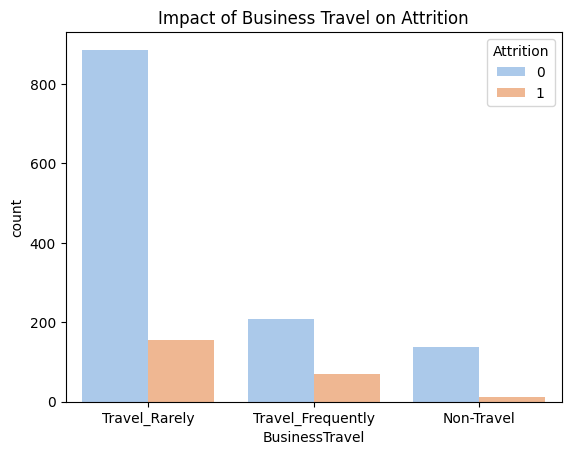

In [ ]:
sns.countplot(hue=df.Attrition, x=df.BusinessTravel,palette='pastel')
plt.title('Impact of Business Travel on Attrition')
plt.show()

**2. IMPACT OF DEPARTMENT ON ATTRITION**

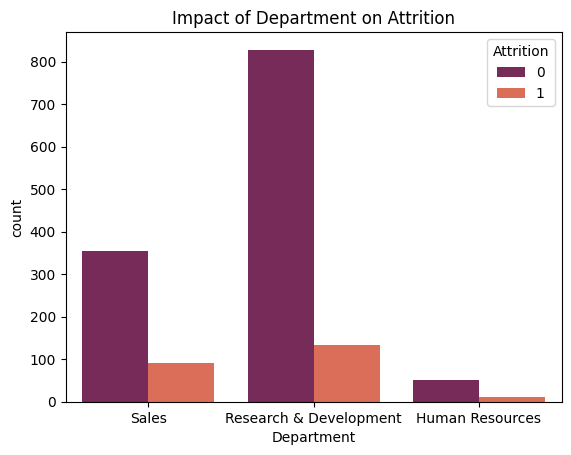

In [ ]:
sns.countplot(hue=df.Attrition, x=df.Department, palette='rocket')
plt.title('Impact of Department on Attrition')
plt.show()

**IMPACT OF EDUCATION FIELD ON ATTRITION**

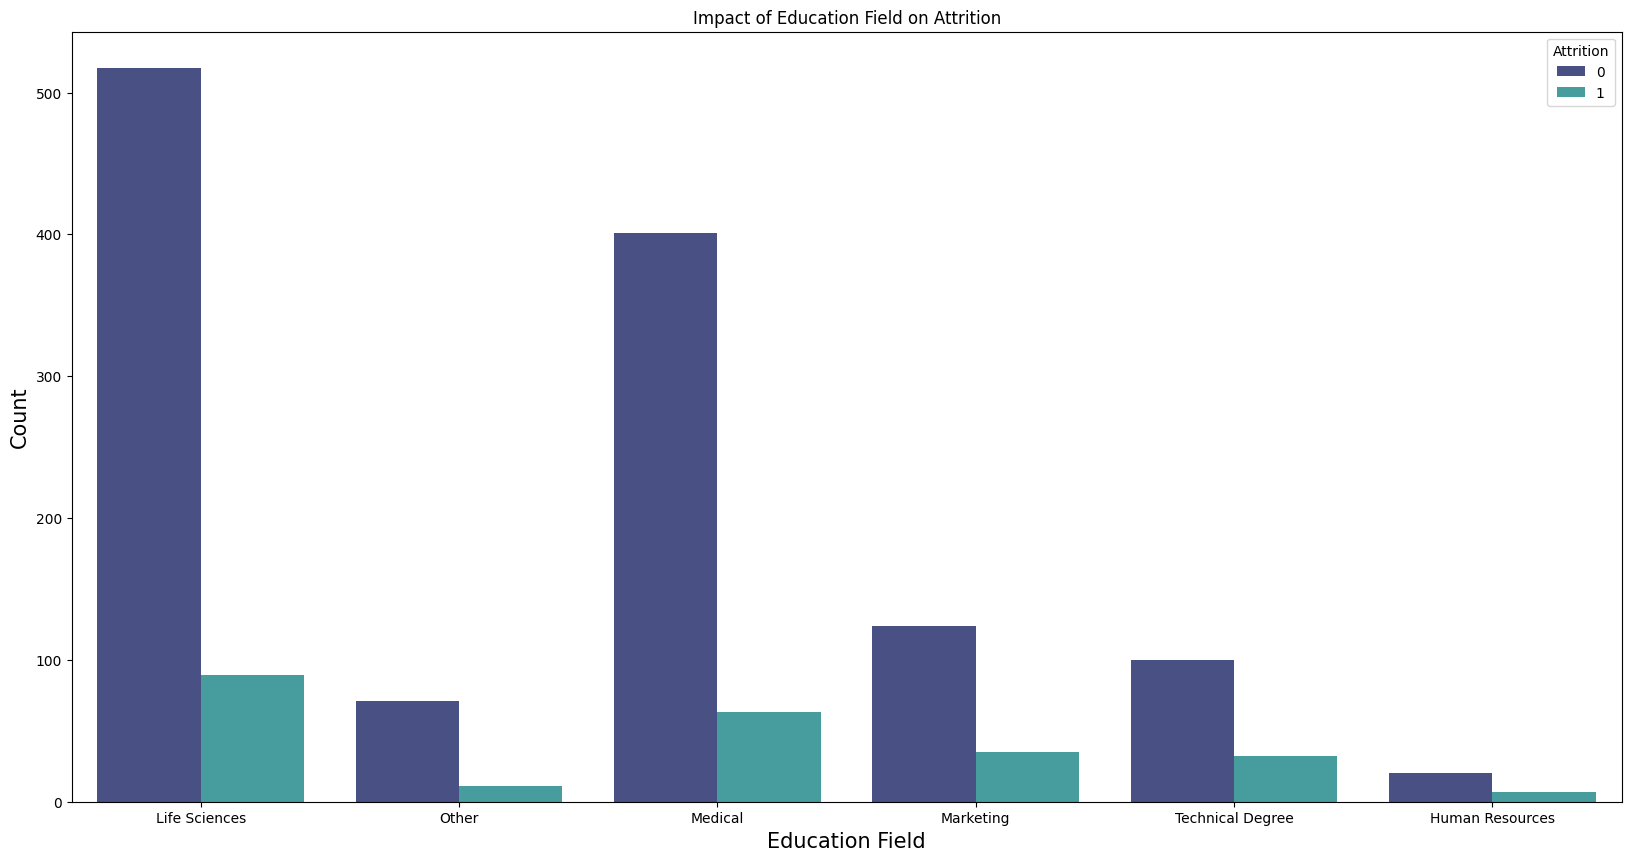

In [ ]:
plt.figure(figsize=(20,10), facecolor='white')
sns.countplot(hue=df.Attrition, x=df.EducationField, palette='mako')
plt.title("Impact of Education Field on Attrition")
plt.xlabel("Education Field", fontdict={'fontsize':15})
plt.ylabel("Count", fontdict={'fontsize':15})
plt.show()
# here 0= no of employees

**4.IMPACT OF GENDER ON ATTRITION**

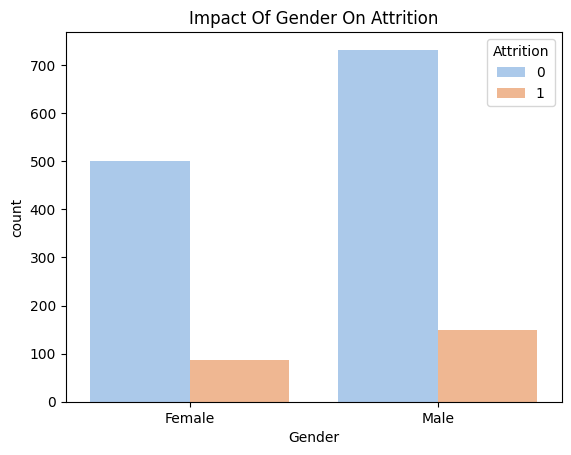

In [ ]:
sns.countplot(x=df.Gender,hue=df.Attrition, palette='pastel')
plt.title('Impact Of Gender On Attrition')
plt.show()

**5. IMPACT OF OVERTIME ON ATTRITION**

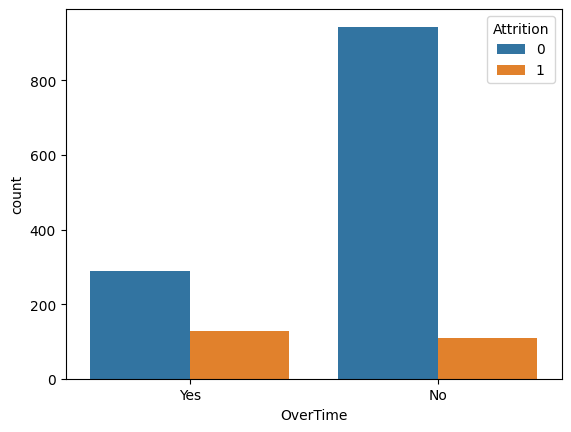

In [ ]:
sns.countplot(x=df.OverTime,hue=df.Attrition)
plt.show()

**5. IMPACT OF JOB ROLE ON ATTRITION**

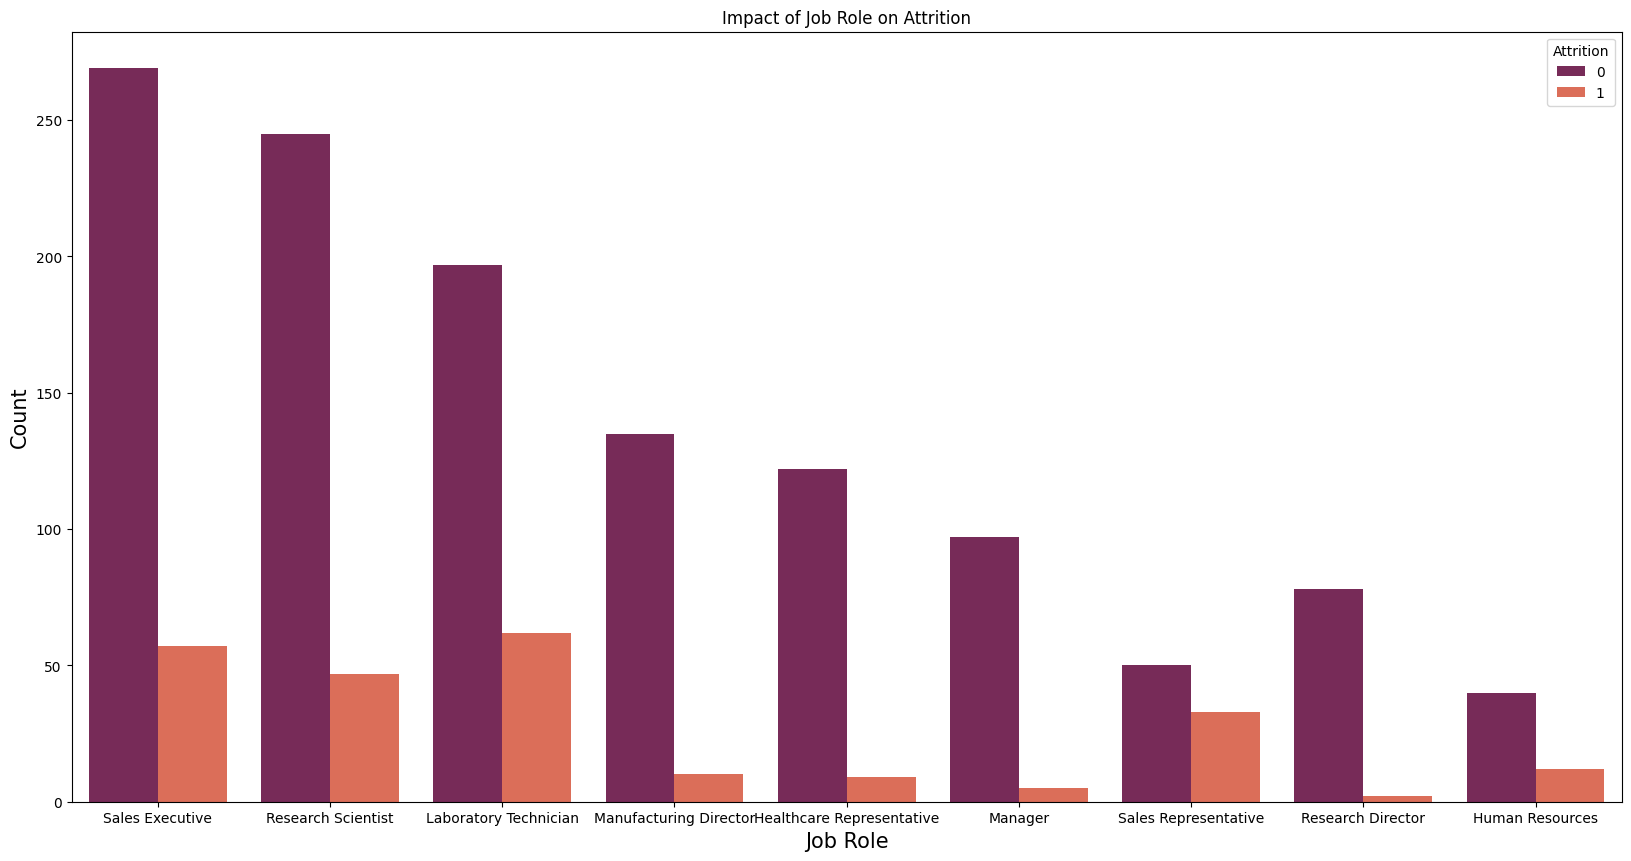

In [ ]:
plt.figure(figsize=(20,10), facecolor='white')
sns.countplot(hue=df.Attrition, x=df.JobRole, palette='rocket')
plt.title('Impact of Job Role on Attrition')
plt.xlabel('Job Role', fontsize=15)
plt.ylabel('Count', fontsize=15)

plt.show()

**6. IMPACT OF AGE ON ATTRITION**

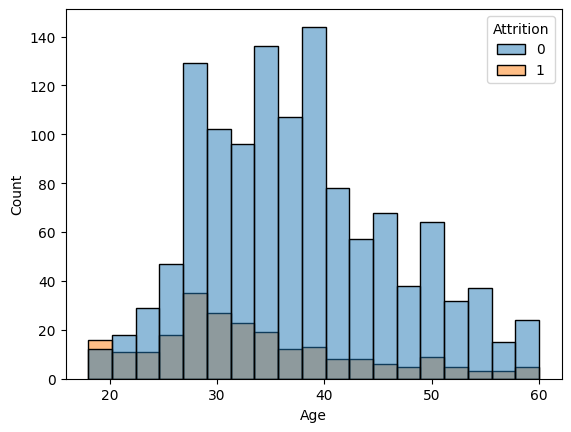

In [ ]:
sns.histplot(x=df.Age, hue=df.Attrition)
plt.show()

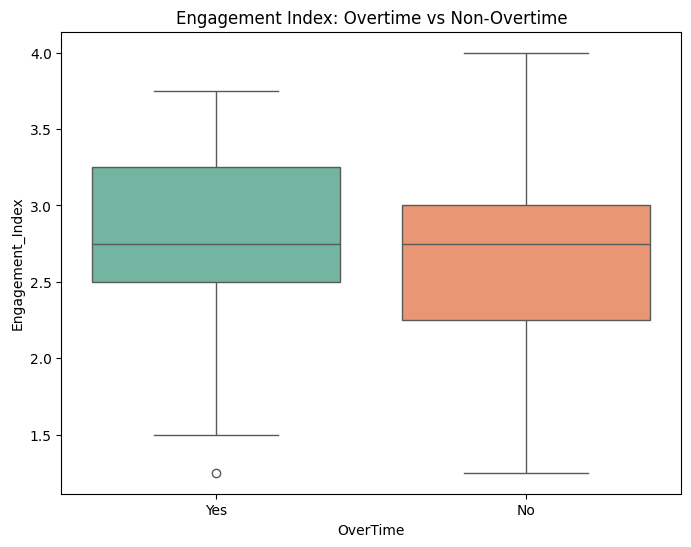

In [ ]:
plt.figure(figsize=(8,6))
sns.boxplot(x='OverTime', y='Engagement_Index', data=df, hue='OverTime', palette="Set2", legend=False)
plt.title("Engagement Index: Overtime vs Non-Overtime")
plt.show()


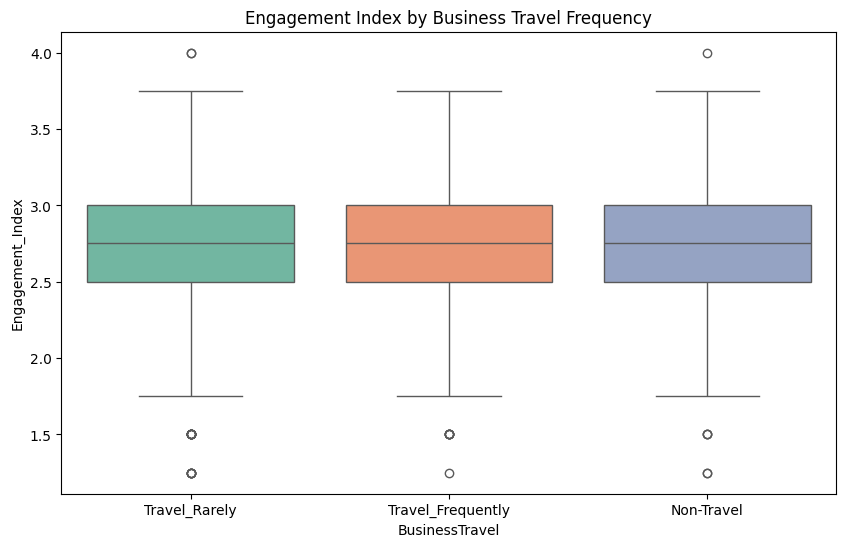

In [ ]:
#Business Travel Impact
plt.figure(figsize=(10,6))
sns.boxplot(x='BusinessTravel', y='Engagement_Index', data=df, hue='BusinessTravel', palette="Set2", legend=False)
plt.title("Engagement Index by Business Travel Frequency")
plt.show()


/tmp/ipykernel_1366/2384655797.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




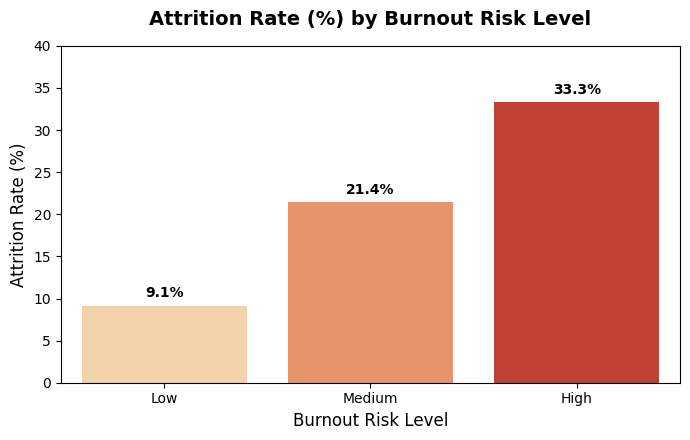

In [ ]:
# Plot 1: Attrition Rate % by Burnout Risk Level
risk_attrition = df.groupby('Burnout_Risk')['Attrition'].mean().reset_index()
risk_attrition['Attrition_Pct'] = risk_attrition['Attrition'] * 100


plt.figure(figsize=(7, 4.5))
sns.barplot(x='Burnout_Risk', y='Attrition_Pct', data=risk_attrition, order=['Low', 'Medium', 'High'], palette='OrRd')
plt.title('Attrition Rate (%) by Burnout Risk Level', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Burnout Risk Level', fontsize=12)
plt.ylabel('Attrition Rate (%)', fontsize=12)
for index, row in risk_attrition.iterrows():
    # map order to index
    order_idx = {'Low': 0, 'Medium': 1, 'High': 2}[row['Burnout_Risk']]
    plt.text(order_idx, row['Attrition_Pct'] + 1, f"{row['Attrition_Pct']:.1f}%", color='black', ha="center", fontweight='bold')
plt.ylim(0, 40)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1366/600536343.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




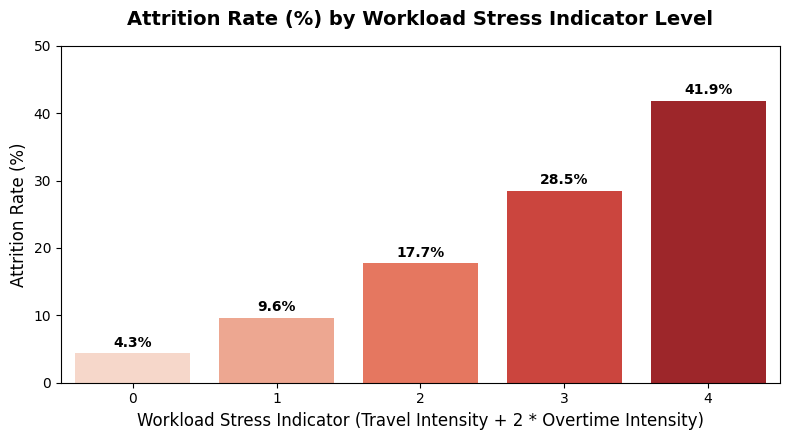

In [ ]:
# Plot 2: Attrition Rate by Workload Stress Indicator
stress_attrition = df.groupby('Workload_Stress_Indicator')['Attrition'].mean().reset_index()
stress_attrition['Attrition_Pct'] = stress_attrition['Attrition'] * 100

plt.figure(figsize=(8, 4.5))
sns.barplot(x='Workload_Stress_Indicator', y='Attrition_Pct', data=stress_attrition, palette='Reds')
plt.title('Attrition Rate (%) by Workload Stress Indicator Level', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Workload Stress Indicator (Travel Intensity + 2 * Overtime Intensity)', fontsize=12)
plt.ylabel('Attrition Rate (%)', fontsize=12)
for index, row in stress_attrition.iterrows():
    plt.text(row['Workload_Stress_Indicator'], row['Attrition_Pct'] + 1, f"{row['Attrition_Pct']:.1f}%", color='black', ha="center", fontweight='bold')
plt.ylim(0, 50)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1366/515913168.py:1: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




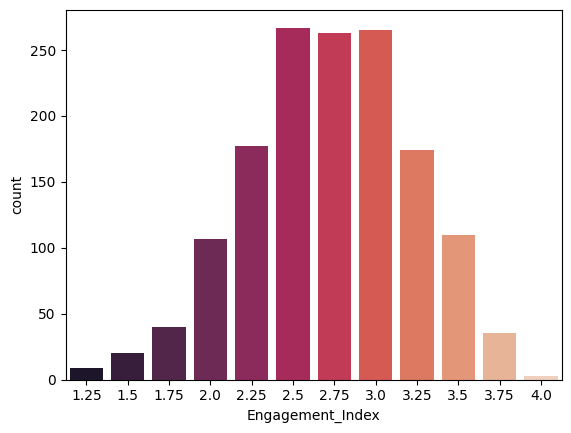

In [ ]:
sns.countplot(x=df.Engagement_Index, palette='rocket')
title='Employee Engagement Distribution'
plt.show()

/tmp/ipykernel_1366/14776722.py:1: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




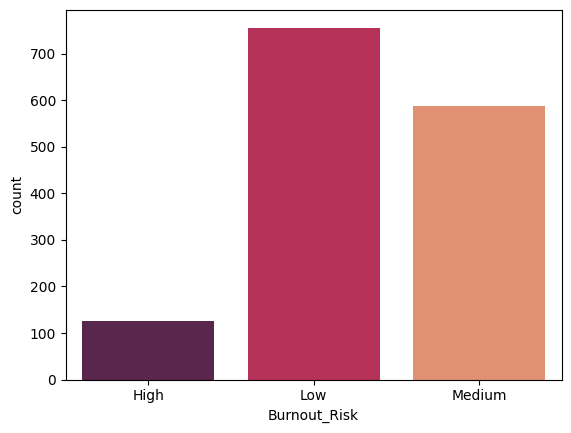

In [ ]:
sns.countplot(x=df.Burnout_Risk, palette='rocket')
title='Burnout Risk Distribution'
plt.show()

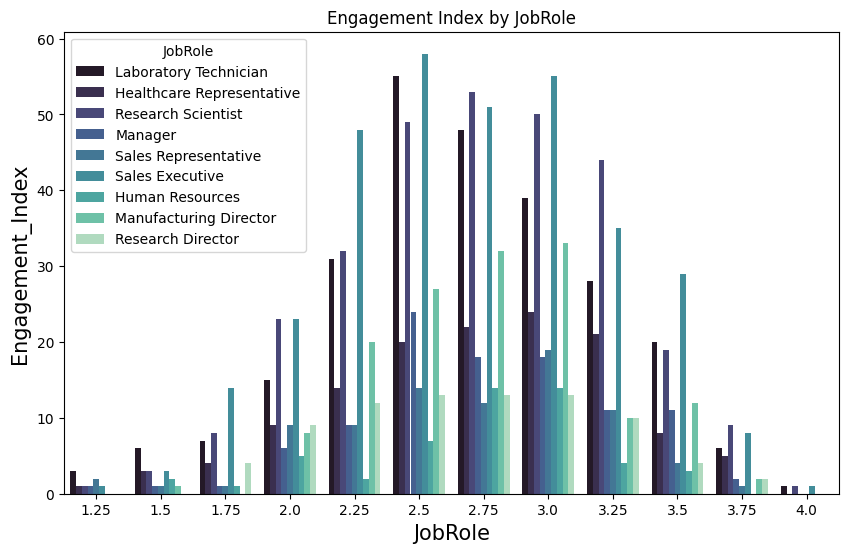

In [497]:
plt.figure(figsize=(10,6), facecolor='white')
sns.countplot(hue=df.JobRole, x=df.Engagement_Index, palette='mako')
plt.title("Engagement Index by JobRole")
plt.xlabel("JobRole", fontdict={'fontsize':15})
plt.ylabel("Engagement_Index", fontdict={'fontsize':15})
plt.show()
# here 0= no of employees

In [ ]:
role_engagement = df.groupby('JobRole')[
    'Engagement_Index'
].mean().reset_index()

fig = px.bar(
    role_engagement,
    x='JobRole',
    y='Engagement_Index',
    title='Engagement by Job Role'
)

fig.show()

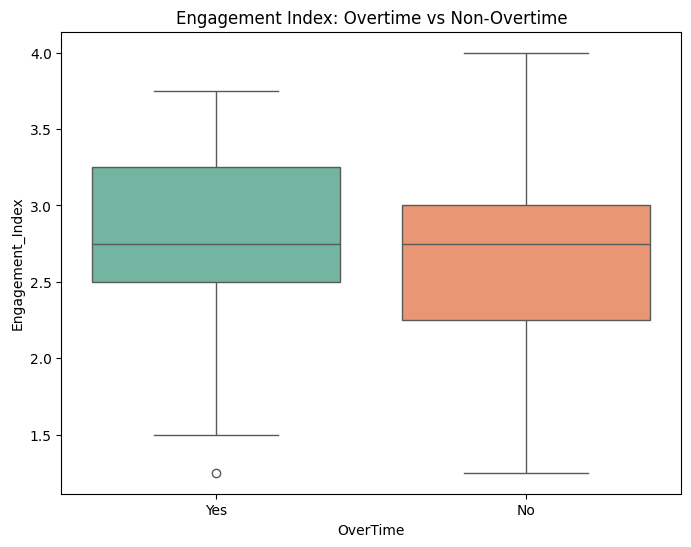

In [ ]:
# Workload & Stress Analysis
f['LongCommute'] = df['DistanceFromHome'] > 10

# 1. Overtime Impact
plt.figure(figsize=(8,6))
sns.boxplot(x='OverTime', y='Engagement_Index', data=df, hue='OverTime', palette="Set2", legend=False)
plt.title("Engagement Index: Overtime vs Non-Overtime")
plt.show()

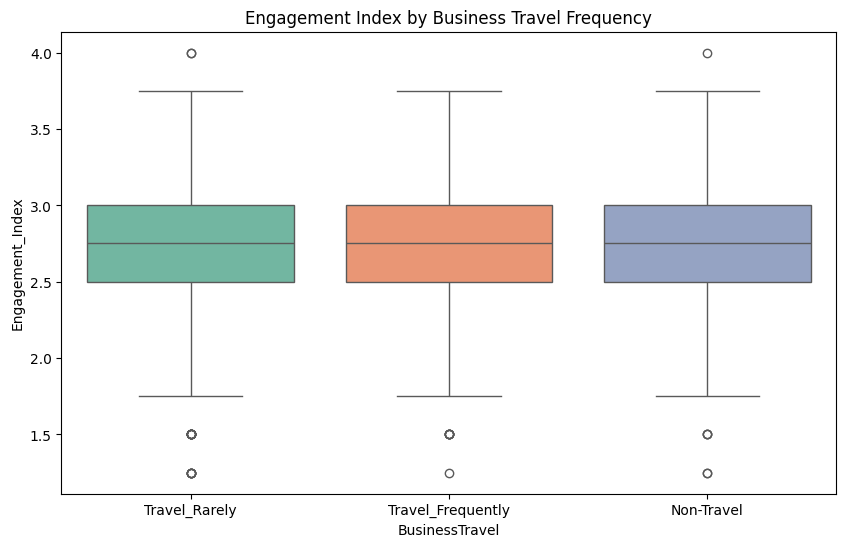

In [ ]:
# 2. Business Travel Impact
plt.figure(figsize=(10,6))
sns.boxplot(x='BusinessTravel', y='Engagement_Index', data=df, hue='BusinessTravel', palette="Set2", legend=False)
plt.title("Engagement Index by Business Travel Frequency")
plt.show()

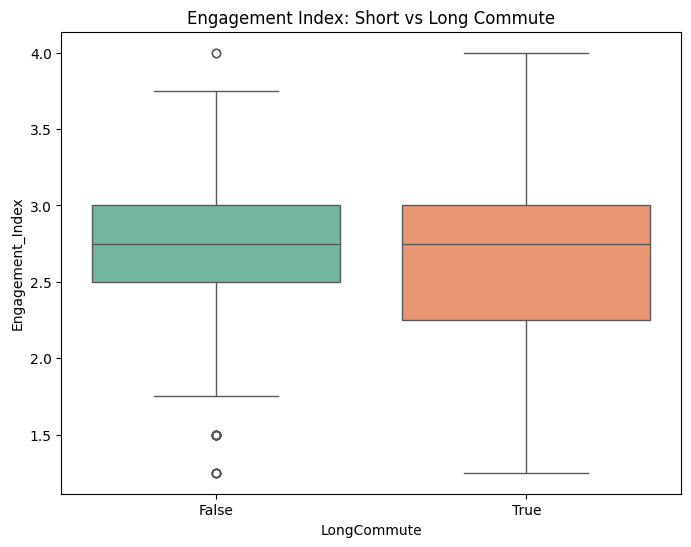

In [ ]:
# 3. Long Commute Impact
plt.figure(figsize=(8,6))
sns.boxplot(x='LongCommute', y='Engagement_Index', data=df, hue='LongCommute', palette="Set2", legend=False)
plt.title("Engagement Index: Short vs Long Commute")
plt.show()


StagnationRisk
False    2.722363
True     2.726316
Name: Engagement_Index, dtype: float64


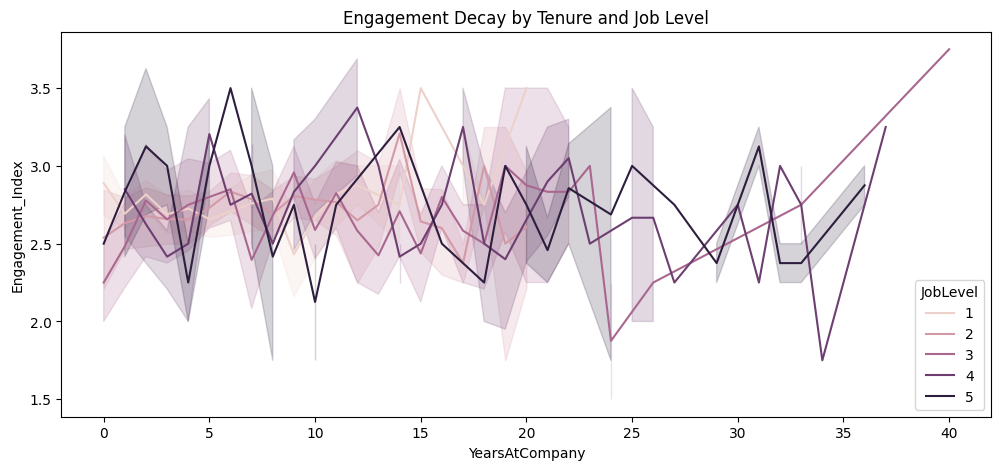

In [ ]:
 # 4: Career-Stage Engagement Analysis

# Line plot trends
plt.figure(figsize=(12,5))
sns.lineplot(x='YearsAtCompany', y='Engagement_Index', hue='JobLevel', data=df, errorbar=('ci', 95))
plt.title("Engagement Decay by Tenure and Job Level")

# Stagnation flag (YearsInCurrentRole > 3 AND no promotion)
df['StagnationRisk'] = (df['YearsInCurrentRole'] > 3) & (df['YearsSinceLastPromotion'] > 3)
print(df.groupby('StagnationRisk')['Engagement_Index'].mean())
plt.show()

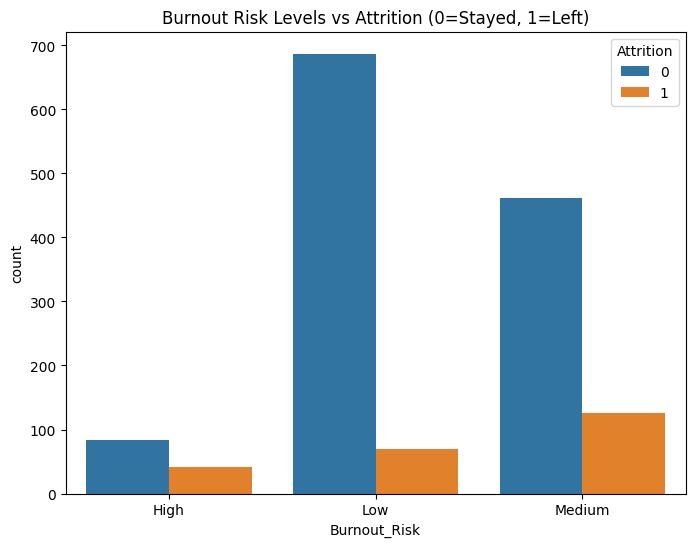

In [ ]:
 #Burnout Risk Identification ======================
plt.figure(figsize=(8,6))
sns.countplot(x='Burnout_Risk', hue='Attrition', data=df)
plt.title("Burnout Risk Levels vs Attrition (0=Stayed, 1=Left)")
plt.show()

In [503]:
fig = px.scatter(
    df,
    x='YearsAtCompany',
    y='Engagement_Index',
    color='Burnout_Risk',
    title='Tenure vs Engagement'
)

fig.show()

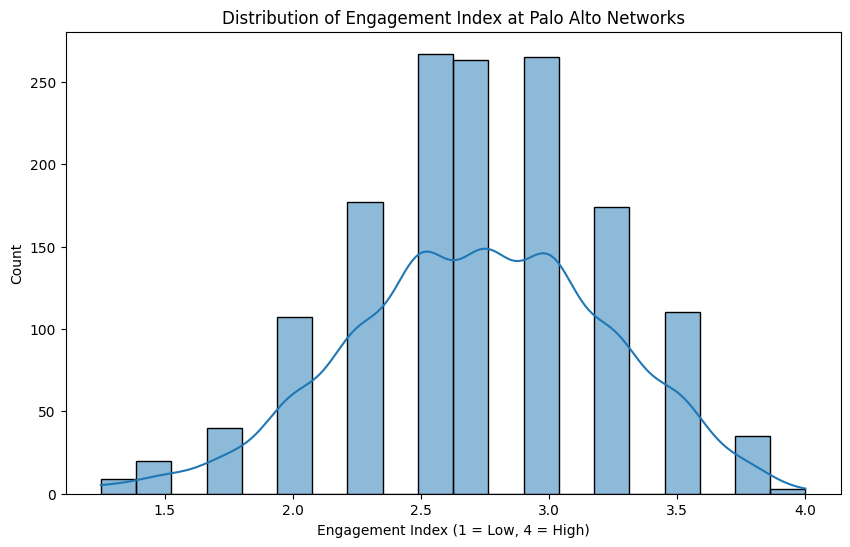

In [ ]:
# Engagement index
plt.figure(figsize=(10,6))
sns.histplot(df['Engagement_Index'], kde=True, bins=20)
plt.title("Distribution of Engagement Index at Palo Alto Networks")
plt.xlabel("Engagement Index (1 = Low, 4 = High)")
plt.show()
